#APE 06 - Distribuciones Continua - Notables

### Integrantes:

* Willan Granda
* Fernando Aguirre
* Darwin Campoverde
* Byron Coronel
* Axel Jimenez

### **Asignatura:** Teoría de la Distribución y Probabilidad  

### **Ciclo:** 2 "A"

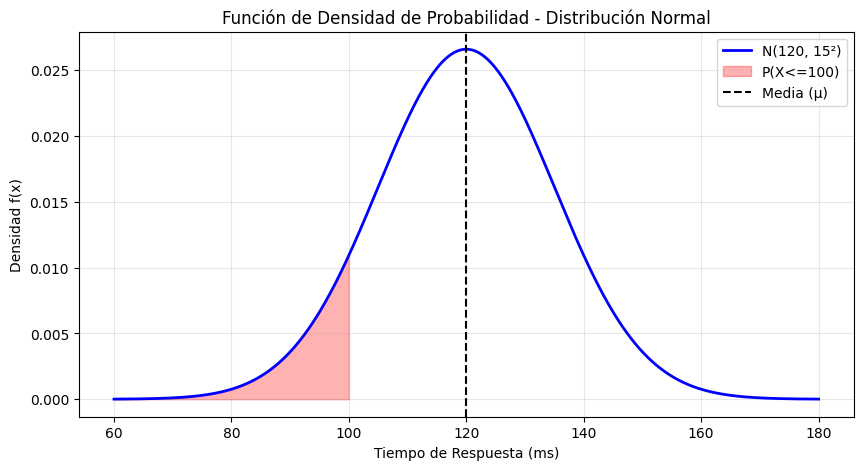

La probabilidad de que el servidor responda en 100ms o menos es: 0.0912 (9.12%)


In [ ]:
# ================================================================
# TAREA 1 - Modelado Matemático y Visualización de la Curva Normal
# ================================================================


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros poblacionales
mu = 120 # [cite: 59]
sigma = 15 # [cite: 60]

# Definición del dominio (eje X): usualmente de mu-4sigma a mu+4sigma [cite: 61]
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000) #

# Cálculo de la PDF teórica (Corregido '1oc' por 'loc' y 'scale sigma' por 'scale=sigma')
pdf_normal = norm.pdf(x, loc=mu, scale=sigma) #

# Configuración del gráfico [cite: 65]
plt.figure(figsize=(10,5)) # [cite: 66]
plt.plot(x, pdf_normal, 'b', lw=2, label=f'N({mu}, {sigma}²)') # [cite: 67]

# Sombreado del área de interés: P(X<=100) [cite: 68]
x_fill = np.linspace(mu - 4*sigma, 100) # [cite: 69]
y_fill = norm.pdf(x_fill, loc=mu, scale=sigma) # [cite: 70]
plt.fill_between(x_fill, y_fill, color='red', alpha=0.3, label='P(X<=100)') # [cite: 71]

# Etiquetas y diseño del gráfico
plt.title('Función de Densidad de Probabilidad - Distribución Normal') # [cite: 76]
plt.xlabel('Tiempo de Respuesta (ms)') # [cite: 77, 78]
plt.ylabel('Densidad f(x)') # [cite: 79, 80]
plt.axvline(mu, color='k', linestyle='--', label='Media (μ)') # [cite: 81] (Cambiado a '--' para mejor visibilidad)
plt.legend() # [cite: 82]
plt.grid(True, alpha=0.3) # [cite: 83]
plt.show() # [cite: 84]

# Cálculo analítico de la probabilidad usando CDF [cite: 85]
# (Corregido el error de comillas y el scale=sigma)
prob_100 = norm.cdf(100, loc=mu, scale=sigma) # [cite: 86]
print(f"La probabilidad de que el servidor responda en 100ms o menos es: {prob_100:.4f} ({prob_100*100:.2f}%)") # [cite: 87]

In [ ]:
# ================================================
# TAREA 2 -Estandarización y Cálculo de Valores Z
# ================================================

from scipy.stats import norm

# Parámetros poblacionales definidos en la Tarea 1
mu = 120
sigma = 15

# Valor de la variable a evaluar (tiempo de respuesta lento)
X = 145

# 1. Cálculo manual del valor Z
# La estandarización transforma nuestra variable a una Normal Estándar Z ~ N(0,1)
Z = (X - mu) / sigma
print(f"El valor Z para X={X} es: {Z:.4f}")

# 2. Cálculo de la probabilidad P(X >= 145)

prob = 1 - norm.cdf(Z, loc=0, scale=1)
print(f"La probabilidad P(X >= 145) es: {prob:.4f} ({prob*100:.2f}%)")

El valor Z para X=145 es: 1.6667
La probabilidad P(X >= 145) es: 0.0478 (4.78%)


In [ ]:
# ==========================================
# TAREA 3 - APLICACIÓN PROBABILÍSTICA REGIONAL
# ==========================================

# 1. Importar librerías
import pandas as pd
from scipy.stats import norm
from google.colab import files

# 2. Cargar dataset
uploaded = files.upload()

# Obtener el nombre del archivo subido
archivo = list(uploaded.keys())[0]

# Leer el archivo CSV
df = pd.read_csv(
    archivo,
    sep=';',
    encoding='latin-1'
)

# Mostrar primeras filas
print("Primeras filas del dataset:")
print(df.head())

# ==========================================
# 3. Seleccionar variable continua
# ==========================================

# Se utilizará la temperatura media de diciembre (columna 'dic')
datos_variable = pd.to_numeric(
    df['dic'].astype(str).str.replace(',', '.'),
    errors='coerce'
).dropna()

# ==========================================
# 4. Calcular media y desviación estándar
# ==========================================

media = datos_variable.mean()
desviacion = datos_variable.std()

print("\nESTADÍSTICOS MUESTRALES")
print(f"Media muestral (μ): {media:.2f} °C")
print(f"Desviación estándar muestral (σ): {desviacion:.2f} °C")

# ==========================================
# 5. Escenario problemático
# ==========================================

print("\nESCENARIO PROBLEMÁTICO")
print("¿Cuál es la probabilidad de que una estación meteorológica")
print("registre una temperatura media de diciembre inferior a 15 °C?")

# ==========================================
# 6. Cálculo de probabilidad
# ==========================================

limite = 15

probabilidad = norm.cdf(
    limite,
    loc=media,
    scale=desviacion
)

print(f"\nProbabilidad calculada: {probabilidad:.4f}")
print(f"Porcentaje: {probabilidad*100:.2f}%")

# ==========================================
# 7. Interpretación
# ==========================================

print("\nINTERPRETACIÓN")

if probabilidad > 0.5:
    print(
        f"Existe una probabilidad de {probabilidad*100:.2f}% "
        f"de que una estación meteorológica registre una "
        f"temperatura media inferior a {limite} °C durante diciembre."
    )
else:
    print(
        f"La probabilidad de registrar una temperatura media "
        f"inferior a {limite} °C durante diciembre es de "
        f"{probabilidad*100:.2f}%, por lo que este evento "
        f"es relativamente poco frecuente."
    )

Saving inamhi-temperaturamedia-2019diciembre.csv to inamhi-temperaturamedia-2019diciembre.csv
Primeras filas del dataset:
  Estacion NombreEstacion longitud2 latitud2  altitud  anio   ene   feb   mar  \
0    M0001      INGUINCHO   -78,408   0,2575     3140  1978    10  10,8  10,2   
1    M0001      INGUINCHO   -78,408   0,2575     3140  1979  10,3  10,3  10,3   
2    M0001      INGUINCHO   -78,408   0,2575     3140  1980  10,6    10  10,4   
3    M0001      INGUINCHO   -78,408   0,2575     3140  1981  10,3  10,5  10,5   
4    M0001      INGUINCHO   -78,408   0,2575     3140  1982   9,9  10,4  10,3   

    abr   may   jun  jul  ago   sep   oct   nov   dic  
0  10,3  10,2   9,5  9,2  9,3   9,7   9,6  11,3  10,2  
1  10,4  10,3    10  9,6  9,5  10,2  10,3  10,3  10,3  
2  10,5  10,5  10,1  9,7  9,6  10,4  10,3  10,4  10,3  
3  10,6  10,3   9,9  9,3  9,7    10  10,5  10,1  10,3  
4  10,4  10,4  10,2  9,4  9,5  10,1    10  10,7  10,7  

ESTADÍSTICOS MUESTRALES
Media muestral (μ): 19.68 °C
D

Saving inamhi-temperaturamedia-2019diciembre.csv to inamhi-temperaturamedia-2019diciembre (1).csv


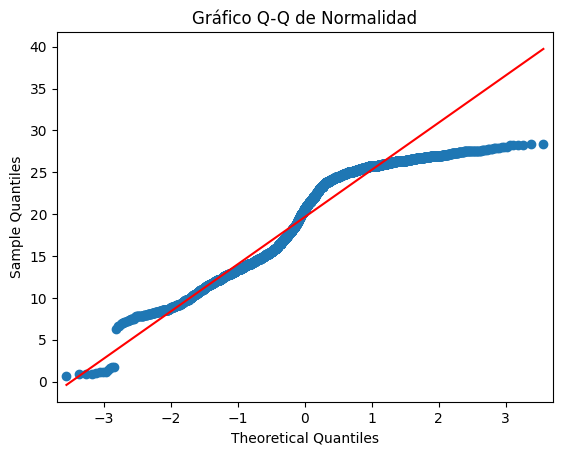

RESULTADOS DEL TEST DE SHAPIRO-WILK
Estadístico de Shapiro: 0.9208
p-valor: 8.7332e-47

CONCLUSIÓN:
Se rechaza la hipótesis nula de normalidad.
Los datos no siguen una distribución normal.


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5433.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
# ==========================================
# TAREA 4 - VALIDACIÓN DEL SUPUESTO DE NORMALIDAD
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import shapiro
from google.colab import files

# Cargar archivo
uploaded = files.upload()

archivo = list(uploaded.keys())[0]

df = pd.read_csv(
    archivo,
    sep=';',
    encoding='latin-1'
)

# Variable utilizada en la Tarea 3
datos_variable = pd.to_numeric(
    df['dic'].astype(str).str.replace(',', '.'),
    errors='coerce'
).dropna()

# ==========================================
# 1. MÉTODO GRÁFICO: Q-Q Plot
# ==========================================

sm.qqplot(datos_variable, line='s')
plt.title('Gráfico Q-Q de Normalidad')
plt.show()

# ==========================================
# 2. MÉTODO ANALÍTICO: Shapiro-Wilk
# ==========================================

stat, p_value = shapiro(datos_variable)

print("RESULTADOS DEL TEST DE SHAPIRO-WILK")
print(f"Estadístico de Shapiro: {stat:.4f}")
print(f"p-valor: {p_value:.4e}")

# ==========================================
# 3. CONCLUSIÓN
# ==========================================

alpha = 0.05

if p_value > alpha:
    print("\nCONCLUSIÓN:")
    print("No se rechaza la hipótesis nula de normalidad.")
    print("Los datos pueden considerarse aproximadamente normales.")
else:
    print("\nCONCLUSIÓN:")
    print("Se rechaza la hipótesis nula de normalidad.")
    print("Los datos no siguen una distribución normal.")

# PREGUNTAS DE CONTROL

### 1. Matemáticamente, ¿por qué en una variable aleatoria continua modelada por una función de densidad f(x) , la probabilidad de que tome un valor exacto es cero, es decir, P(X = c) = 0?

Porque en una variable aleatoria continua, la probabilidad se representa mediante el área bajo la curva de su función de densidad. Dado que un valor exacto representa un solo punto en el eje horizontal, su ancho es igual a cero. Al no tener ancho, no se genera ningún área en ese punto, por lo que P(X = c) = 0. Esto ocurre porque hay infinitos valores posibles en un entorno continuo, y la probabilidad de acertar a uno solo de forma exacta es de 1 entre infinito, lo cual es matemáticamente cero.

#### 2. Interprete conceptualmente qué significa que un valor de su dataset regional tenga un puntaje estándar de . ¿Se consideraría un valor atípico bajo el criterio de la regla empírica?

Que un valor de nuestro  dataset regional tenga un puntaje de -2.45 significa que este registro específico se encuentra bastante por debajo del promedio general. Al tener ese número negativo, nos indica que está alejado hacia abajo del centro de los datos. Tomando en cuenta la regla empírica, sí se lo consideraría como un valor atípico, porque la regla nos dice que la gran mayoría de los datos normales o habituales (alrededor del 95%) siempre se agrupan mucho más cerca del promedio, en un rango entre -2 y 2. Como este dato sobrepasa ese límite inferior, alejándose más allá del -2, se sale por completo de ese grupo común y se destaca como un caso inusualmente bajo dentro de la  región.

### 3. En la Tarea 3, calculó probabilidades asumiendo que su variable regional seguía una distribución Normal. ¿Qué riesgo metodológico existe al tomar decisiones basadas en este cálculo si la gráfica de la variable presenta un fuerte sesgo (skewness)?

El principal riesgo metodológico es obtener estimaciones de probabilidad incorrectas, lo que llevaría a tomar decisiones basadas en un escenario irreal. Al presentar un fuerte sesgo, la distribución real de los datos es asimétrica y se acumula hacia un lado, por lo que no coincide con la forma de campana perfecta y equilibrada del modelo normal. Si se fuerza una distribución normal sobre estos datos sesgados, se calcula de manera errónea la verdadera frecuencia de los eventos, terminando por sobreestimar o subestimar gravemente la probabilidad de que ocurran valores extremos. Por lo que cualquier decisión o planificación basada en este cálculo será muy poco confiable, ya que se estaría actuando sobre una predicción que no refleja el comportamiento genuino de los datos de la región.  

### 4. Con base en la Tarea 4 (ABI), si el p-valor del test de Shapiro-Wilk es , ¿cuál es la conclusión estadística respecto a la distribución de sus datos regionales? ¿Se invalida el cálculo realizado en la Tarea 3?

Si el p-valor del test de Shapiro-Wilk es 0.001, al ser un número mucho menor que el límite de error habitualmente aceptado (0.05), la conclusión estadística es que se rechaza la normalidad; es decir, está comprobado que los datos regionales no siguen una distribución normal. En consecuencia, el resultado práctico del cálculo realizado en la Tarea 3 sí queda invalidado. Porque ese procedimiento matemático se basó enteramente en la suposición de que los datos tenían una forma de campana perfecta, aplicar esa probabilidad a una variable que se comporta de otra manera genera una estimación engañosa y metodológicamente incorrecta para tomar cualquier decisión real.

### 5. Explique el principio matemático detrás del Gráfico Q-Q. ¿Qué representan los cuantiles teóricos en el eje X versus los cuantiles empíricos en el eje Y?

El principio matemático del Gráfico Q-Q (Quantile-Quantile) consiste en comparar los cuantiles de una muestra con los cuantiles de una distribución teórica, por lo general la distribución normal, para evaluar si los datos siguen dicha distribución. Si ambas distribuciones son similares, los puntos del gráfico se alinearán aproximadamente sobre una recta. En el eje X se representan los cuantiles teóricos, que son los valores esperados según la distribución teórica seleccionada, en el eje Y se representan los cuantiles empíricos, que corresponden a los cuantiles obtenidos a partir de los datos observados en la muestra, permitiendo comparar visualmente los datos reales con los valores que se esperarían bajo el modelo teórico. Cuanto más cerca estén los puntos de una línea recta, mayor será la concordancia entre la distribución de los datos y la distribución teórica.